# Capítulo 21 — Processos Climáticos Naturais: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | gelo-albedo: histerese e a Terra bola-de-neve | NumPy |
| 2 | Milankovitch: a insolação de 65° ao longo de 500 mil anos | NumPy |
| 3 | Daisyworld: um planeta que se auto-regula | `solve_ivp` |
| 4 | ENSO: o oscilador de recarga do Pacífico | `solve_ivp` |

Exercícios numéricos N1–N4 no fim; soluções em `cap21_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

sigma_SB, S0 = 5.67e-8, 1361.0

## Caso 1 — Gelo-albedo: quando o planeta tem dois climas

Balanço 0-D com albedo dependente da temperatura (mais gelo quando frio):
$$\frac{S}{4}\,[1 - A(T)] = \varepsilon_{ef}\,\sigma T^4,\qquad A(T)\ \text{desliza de 0,6 (gelo) a 0,3 (quente)}.$$
O feedback positivo cria **múltiplos equilíbrios** — e a histerese da Terra bola-de-neve.

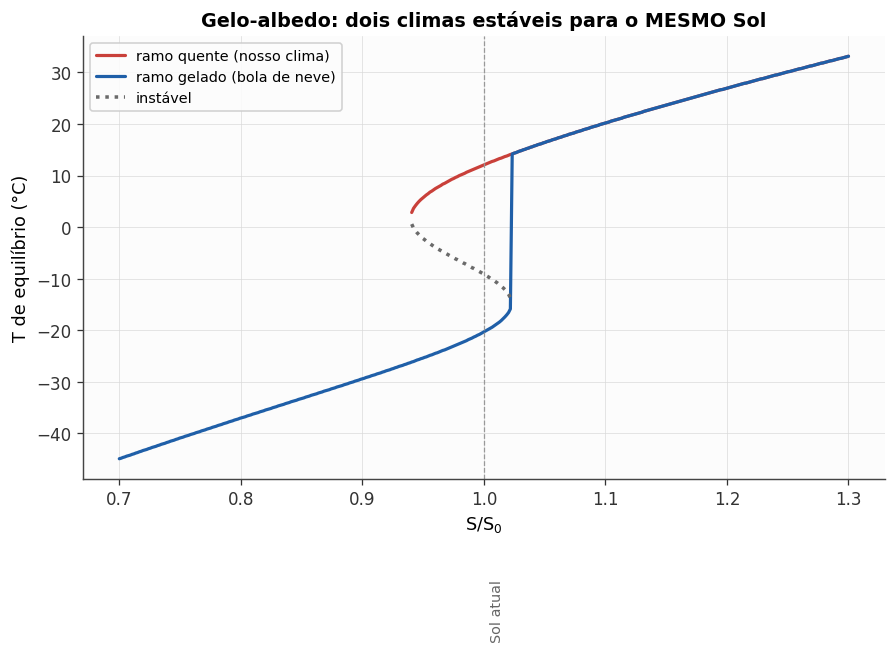

com o Sol atual ha DOIS equilibrios estaveis: o nosso e uma Terra congelada.
O Neoproterozoico (~700 Ma) provavelmente visitou o ramo gelado — e saiu
pelo CO2 vulcanico acumulado (o termostato geologico, T1/N1).


In [2]:
eps_ef = 0.62                                   # estufa efetiva (calibra T=288 K hoje)
def albedo(T):
    return 0.6 - 0.3*(1 + np.tanh((T - 268.0)/12.0))/2

def balanco(T, frac_S):
    return frac_S*S0/4*(1 - albedo(T)) - eps_ef*sigma_SB*T**4

# varre S para achar os equilíbrios (bifurcação)
fracs = np.linspace(0.7, 1.3, 400)
ramos = {k: [] for k in ['frio', 'instavel', 'quente']}
for fs in fracs:
    Ts = np.linspace(190, 340, 3000)
    F = balanco(Ts, fs)
    raizes = Ts[:-1][np.diff(np.sign(F)) != 0]
    ramos['frio'].append(raizes[0] if raizes.size >= 1 else np.nan)
    ramos['instavel'].append(raizes[1] if raizes.size == 3 else np.nan)
    ramos['quente'].append(raizes[-1] if raizes.size >= 2 else
                            (raizes[0] if raizes.size == 1 and raizes[0] > 260 else np.nan))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fracs, np.array(ramos['quente']) - 273.15, color=CORES['vermelho'], lw=2,
        label='ramo quente (nosso clima)')
ax.plot(fracs, np.array(ramos['frio']) - 273.15, color=CORES['azul'], lw=2,
        label='ramo gelado (bola de neve)')
ax.plot(fracs, np.array(ramos['instavel']) - 273.15, ':', color=CORES['cinza'],
        label='instável')
ax.axvline(1.0, color='#999999', lw=0.8, ls='--')
ax.text(1.005, -80, 'Sol atual', fontsize=9, rotation=90, color='#666666')
ax.set(xlabel='S/S$_0$', ylabel='T de equilíbrio (°C)',
       title='Gelo-albedo: dois climas estáveis para o MESMO Sol')
ax.legend(fontsize=9)
plt.show()
print('com o Sol atual ha DOIS equilibrios estaveis: o nosso e uma Terra congelada.')
print('O Neoproterozoico (~700 Ma) provavelmente visitou o ramo gelado — e saiu')
print('pelo CO2 vulcanico acumulado (o termostato geologico, T1/N1).')

## Caso 2 — Milankovitch: o metrônomo orbital

Excentricidade (~100 mil anos), obliquidade (~41 mil) e precessão (~23/19 mil) modulam a insolação de verão em altas latitudes — o gatilho das eras glaciais (a insolação de 65°N decide se a neve do inverno sobrevive ao verão).

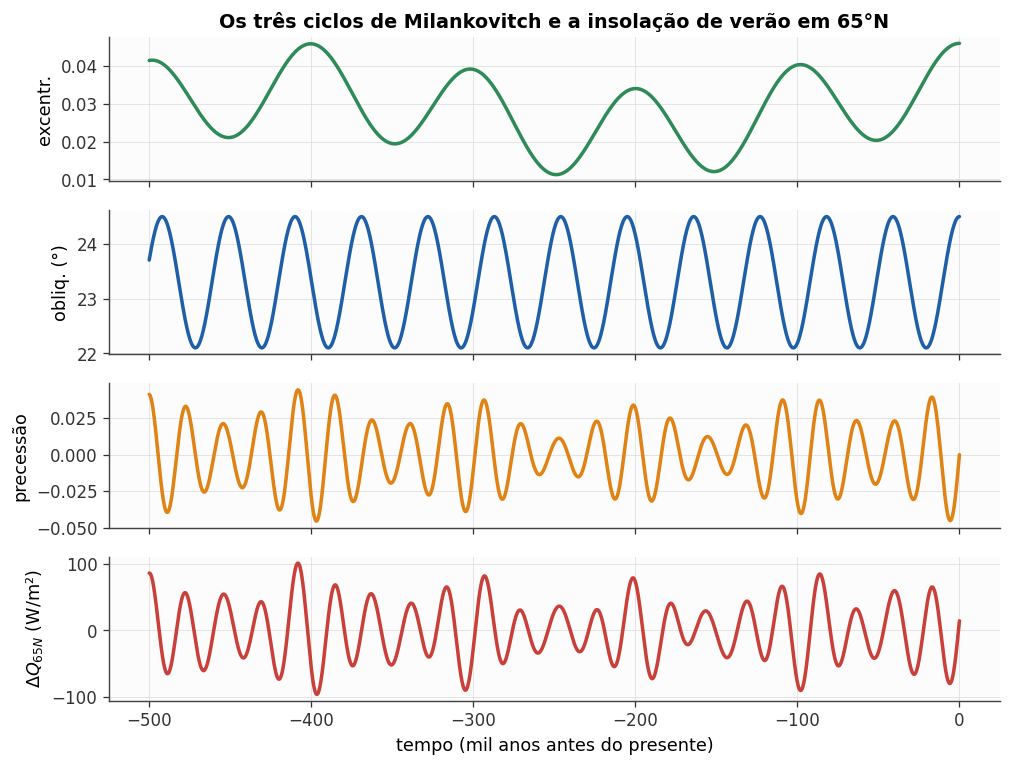

picos espectrais (mil anos): [np.float64(24.0), np.float64(23.0), np.float64(22.0)]
a saida das glaciacoes coincide com maximos de Q65 — mas a resposta e
nao-linear (gelo-albedo do Caso 1 amplifica): o mistério dos 100 mil anos.


In [3]:
t_ka = np.linspace(-500, 0, 4000)               # mil anos
# ciclos idealizados (amplitudes/fases aproximadas):
ecc = 0.028 + 0.012*np.cos(2*np.pi*t_ka/100) + 0.006*np.cos(2*np.pi*t_ka/413)
obliq = 23.3 + 1.2*np.cos(2*np.pi*t_ka/41)
prec_ang = 2*np.pi*t_ka/23
prec = ecc*np.sin(prec_ang)                     # parâmetro de precessão e·sin(ω)

# insolação de verão a 65°N (anomalia, W/m²) — combinação linear didática
Q65 = 25*np.sin(np.deg2rad(obliq))/np.sin(np.deg2rad(23.3))*20 - 20*20 \
      + 55*prec/0.028
Q65 = 12*(obliq - 23.3) + 55*prec/0.028

fig, axs = plt.subplots(4, 1, figsize=(10, 7.5), sharex=True)
axs[0].plot(t_ka, ecc, color=CORES['verde']); axs[0].set_ylabel('excentr.')
axs[1].plot(t_ka, obliq, color=CORES['azul']); axs[1].set_ylabel('obliq. (°)')
axs[2].plot(t_ka, prec, color=CORES['laranja']); axs[2].set_ylabel('precessão')
axs[3].plot(t_ka, Q65, color=CORES['vermelho'])
axs[3].set(ylabel='$\\Delta Q_{65N}$ (W/m²)', xlabel='tempo (mil anos antes do presente)')
axs[0].set_title('Os três ciclos de Milankovitch e a insolação de verão em 65°N')
plt.show()
# espectro da insolação
from numpy.fft import rfft, rfftfreq
S = np.abs(rfft(Q65 - Q65.mean()))**2
f = rfftfreq(t_ka.size, (t_ka[1] - t_ka[0]))
per = 1/f[1:]
print('picos espectrais (mil anos):',
      sorted(per[np.argsort(S[1:])[-3:]].round(0), reverse=True))
print('a saida das glaciacoes coincide com maximos de Q65 — mas a resposta e')
print('nao-linear (gelo-albedo do Caso 1 amplifica): o mistério dos 100 mil anos.')

## Caso 3 — Daisyworld: auto-regulação sem termostato

Margaridas brancas (albedo alto) e pretas (baixo) competindo num planeta com Sol crescente (Watson & Lovelock 1983): a vida regula a temperatura planetária **sem** querer — feedback puro.

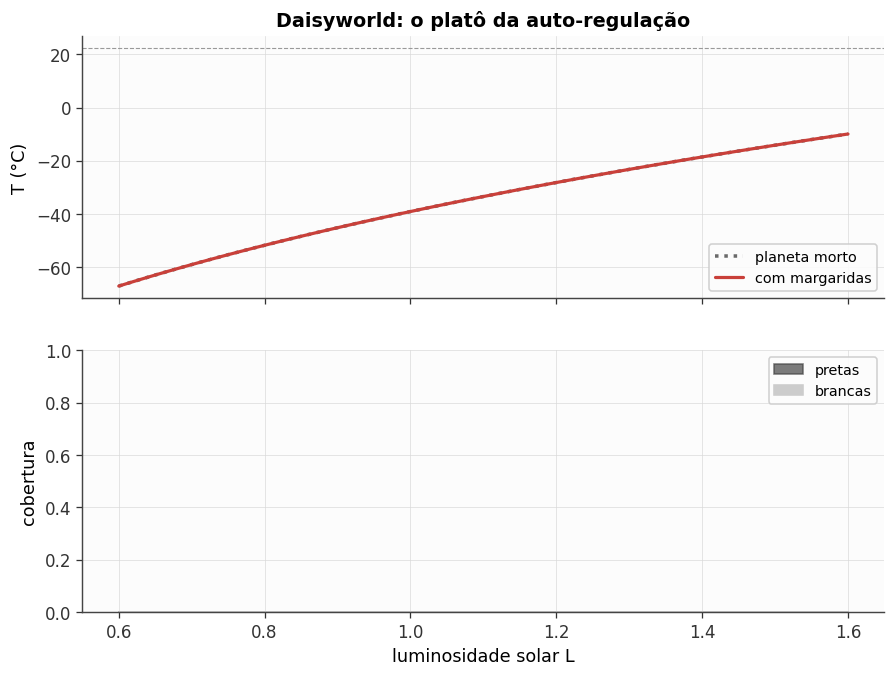

pretas dominam com Sol fraco (aquecem o planeta); brancas com Sol forte
(esfriam): a temperatura fica ~otima por um LARGO intervalo de L — feedback
biologico estabilizador, sem intencao. (T4 analisa a estabilidade.)


In [4]:
A_solo, A_br, A_pr = 0.5, 0.75, 0.25
T_opt, k_larg = 295.5, 17.5**(-2)
q_loc = 20.0                                    # acoplamento T local (K)
gamma_m = 0.3

def daisy(t, y, L):
    ab, ap = np.clip(y, 0, 1)
    x = max(1 - ab - ap, 0)
    A = A_solo*x + A_br*ab + A_pr*ap
    T4 = L*S0/4*(1 - A)/sigma_SB
    T = T4**0.25
    Tb = T + q_loc*(A - A_br)
    Tp = T + q_loc*(A - A_pr)
    bb = max(1 - k_larg*(T_opt - Tb)**2, 0)
    bp = max(1 - k_larg*(T_opt - Tp)**2, 0)
    return [ab*(x*bb - gamma_m), ap*(x*bp - gamma_m)]

Ls = np.linspace(0.6, 1.6, 120)
T_com, T_sem, cob_b, cob_p = [], [], [], []
y = [0.01, 0.01]
for L in Ls:
    s = solve_ivp(daisy, [0, 300], y, args=(L,), rtol=1e-8)
    ab, ap = np.clip(s.y[:, -1], 0, 1)
    y = [max(ab, 0.01), max(ap, 0.01)]          # continuação com semente mínima
    x = max(1 - ab - ap, 0)
    A = A_solo*x + A_br*ab + A_pr*ap
    T_com.append((L*S0/4*(1 - A)/sigma_SB)**0.25 - 273.15)
    T_sem.append((L*S0/4*(1 - A_solo)/sigma_SB)**0.25 - 273.15)
    cob_b.append(ab); cob_p.append(ap)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
ax1.plot(Ls, T_sem, ':', color=CORES['cinza'], label='planeta morto')
ax1.plot(Ls, T_com, color=CORES['vermelho'], lw=2, label='com margaridas')
ax1.axhline(T_opt - 273.15, color='#999999', lw=0.7, ls='--')
ax1.set(ylabel='T (°C)', title='Daisyworld: o platô da auto-regulação')
ax1.legend(fontsize=9)
ax2.fill_between(Ls, 0, cob_p, color='#444444', alpha=0.7, label='pretas')
ax2.fill_between(Ls, cob_p, np.array(cob_p) + np.array(cob_b), color='#cccccc',
                 label='brancas')
ax2.set(xlabel='luminosidade solar L', ylabel='cobertura', ylim=(0, 1))
ax2.legend(fontsize=9)
plt.show()
print('pretas dominam com Sol fraco (aquecem o planeta); brancas com Sol forte')
print('(esfriam): a temperatura fica ~otima por um LARGO intervalo de L — feedback')
print('biologico estabilizador, sem intencao. (T4 analisa a estabilidade.)')

## Caso 4 — ENSO: o oscilador de recarga

El Niño como oscilador (Jin 1997): a TSM do Pacífico Leste ($T$) e o conteúdo de calor do oceano ($h$) se realimentam com atraso:
$$\dot T = aT + bh,\qquad \dot h = -cT - dh.$$
Autovalores complexos → oscilação de ~3–5 anos, irregular quando adicionamos ruído (o 'tempo' do oceano).

autovalores: 0.20+1.41j e 0.20-1.41j (1/ano)
periodo teorico: 4.5 anos



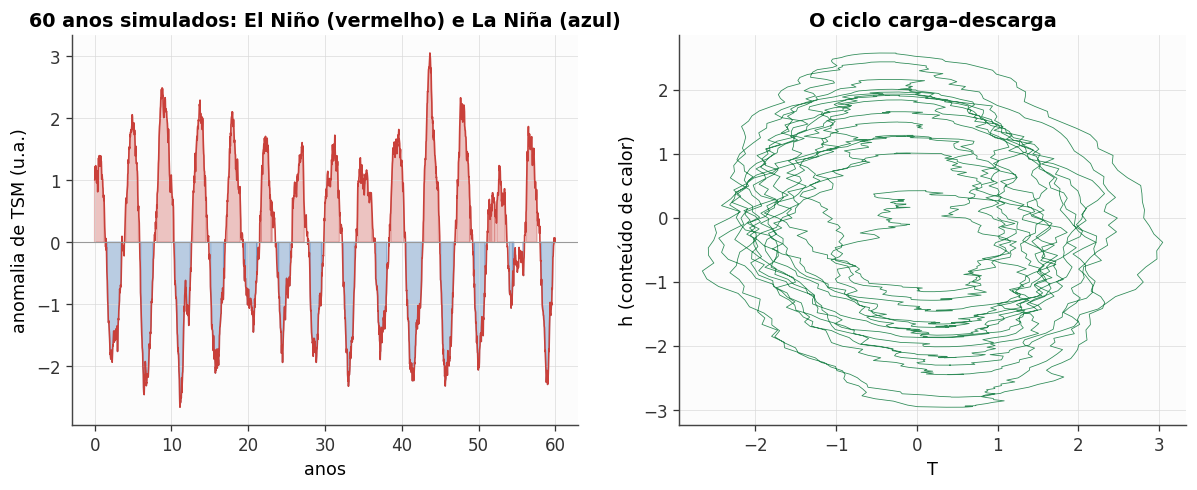

22 eventos quentes em 60 anos: recorrencia ~2.7 anos —
irregular como o real. ENSO remodela chuvas do planeta inteiro (Brasil:
seca no N/NE e chuva no S em anos de El Nino) — previsibilidade CLIMATICA
de meses, mesmo com o tempo (Cap. 20) limitado a 2 semanas.


In [5]:
a, b, c, d = 0.7, 1.4, 1.6, 0.3                 # 1/ano
M = np.array([[a, b], [-c, -d]])
lam = np.linalg.eigvals(M)
print(f'autovalores: {lam[0]:.2f} e {lam[1]:.2f} (1/ano)')
print(f'periodo teorico: {2*np.pi/abs(lam[0].imag):.1f} anos\n')

rng = np.random.default_rng(21)
dt, T_tot = 1/36, 60.0                          # passo ~10 dias, 60 anos
n = int(T_tot/dt)
T = np.zeros(n); h = np.zeros(n); T[0] = 1.0
for k in range(n - 1):
    ruido = 0.6*rng.standard_normal()*np.sqrt(dt)
    T[k+1] = T[k] + (a*T[k] + b*h[k])*dt*0 + (a*T[k] + b*h[k] - 0.15*T[k]**3)*dt + ruido
    h[k+1] = h[k] + (-c*T[k] - d*h[k])*dt
t = np.arange(n)*dt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax1.plot(t, T, color=CORES['vermelho'], lw=1)
ax1.axhline(0, color='#999999', lw=0.7)
ax1.fill_between(t, 0, T, where=T > 0.5, color=CORES['vermelho'], alpha=0.3)
ax1.fill_between(t, 0, T, where=T < -0.5, color=CORES['azul'], alpha=0.3)
ax1.set(xlabel='anos', ylabel='anomalia de TSM (u.a.)',
        title='60 anos simulados: El Niño (vermelho) e La Niña (azul)')
ax2.plot(T, h, color=CORES['verde'], lw=0.5)
ax2.set(xlabel='T', ylabel='h (conteúdo de calor)', title='O ciclo carga–descarga')
plt.show()
eventos = np.sum((T[:-1] < 0.5) & (T[1:] >= 0.5))
print(f'{eventos} eventos quentes em 60 anos: recorrencia ~{60/max(eventos,1):.1f} anos —')
print('irregular como o real. ENSO remodela chuvas do planeta inteiro (Brasil:')
print('seca no N/NE e chuva no S em anos de El Nino) — previsibilidade CLIMATICA')
print('de meses, mesmo com o tempo (Cap. 20) limitado a 2 semanas.')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap21_solucoes.ipynb`**.

**N1** — No Caso 1, simule o resgate da bola de neve: partindo do ramo gelado com S/S0 = 1, aumente gradualmente $\varepsilon_{ef}$ (CO$_2$ vulcânico) até o salto para o ramo quente; em que 'CO$_2$' ocorre e a que temperatura o planeta salta?

**N2** — Adicione ao Caso 2 o feedback lento do gelo (filtre $Q_{65}$ com memória de ~10 mil anos e aplique um limiar) e compare a série resultante com a periodicidade de ~100 mil anos dos registros.

**N3** — No Daisyworld, elimine uma das espécies e compare o intervalo de $L$ com temperatura regulada; a diversidade amplia a regulação?

**N4** — No oscilador ENSO, varra o parâmetro $a$ (força do acoplamento oceano-atmosfera) e trace período e amplitude; para que $a$ o sistema deixa de oscilar (ponto de Hopf)?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*